In [45]:
import pandas as pd 

#https://www.kaggle.com/datasets/pablomgomez21/drugs-a-b-c-x-y-for-decision-trees
data = pd.read_csv('drug200.csv')

data.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


<h4> Examing Data (EDA)

In [46]:
data.Age = pd.to_numeric(data.Age)
data.Na_to_K = pd.to_numeric(data.Na_to_K)
cat_cols = ['Sex', 'BP', 'Cholesterol', 'Drug']
data[cat_cols] = data[cat_cols].astype('category')

In [47]:
data.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   Age          200 non-null    int64   
 1   Sex          200 non-null    category
 2   BP           200 non-null    category
 3   Cholesterol  200 non-null    category
 4   Na_to_K      200 non-null    float64 
 5   Drug         200 non-null    category
dtypes: category(4), float64(1), int64(1)
memory usage: 5.1 KB


In [48]:
data.groupby("Cholesterol")['Sex'].value_counts()

C:\Users\abdur\AppData\Local\Temp\ipykernel_22740\3229769756.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby("Cholesterol")['Sex'].value_counts()


Cholesterol  Sex
HIGH         M      54
             F      49
NORMAL       M      50
             F      47
Name: count, dtype: int64

In [49]:
data.groupby("BP")['Sex'].value_counts()

C:\Users\abdur\AppData\Local\Temp\ipykernel_22740\903255924.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby("BP")['Sex'].value_counts()


BP      Sex
HIGH    M      39
        F      38
LOW     M      36
        F      28
NORMAL  F      30
        M      29
Name: count, dtype: int64

In [50]:
data['Drug'].sort_values().value_counts()

Drug
drugY    91
drugX    54
drugA    23
drugC    16
drugB    16
Name: count, dtype: int64

In [51]:
data.groupby('Drug')[["Sex", "BP","Cholesterol"]].value_counts()

C:\Users\abdur\AppData\Local\Temp\ipykernel_22740\1149844757.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('Drug')[["Sex", "BP","Cholesterol"]].value_counts()


Drug   Sex  BP      Cholesterol
drugA  M    HIGH    NORMAL          8
       F    HIGH    HIGH            6
       M    HIGH    HIGH            6
       F    HIGH    NORMAL          3
            LOW     HIGH            0
                    NORMAL          0
            NORMAL  HIGH            0
                    NORMAL          0
       M    LOW     HIGH            0
                    NORMAL          0
            NORMAL  HIGH            0
                    NORMAL          0
drugB  M    HIGH    HIGH            6
       F    HIGH    NORMAL          4
       M    HIGH    NORMAL          4
       F    HIGH    HIGH            2
            LOW     HIGH            0
                    NORMAL          0
            NORMAL  HIGH            0
                    NORMAL          0
       M    LOW     HIGH            0
                    NORMAL          0
            NORMAL  HIGH            0
                    NORMAL          0
drugC  M    LOW     HIGH            9
       F    LOW   

<h4> Looking at Mutual Information between each feature and the target variable, Drug

In [52]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.feature_selection import mutual_info_classif

X_mi = data[["Sex", "BP", "Cholesterol", "Age"]]
y_mi = data["Drug"]

encoder = OrdinalEncoder()
X_encoded = X_mi.copy()
X_encoded[["Sex", "BP", "Cholesterol"]] = encoder.fit_transform(
    X_encoded[["Sex", "BP", "Cholesterol"]]
)


mi = mutual_info_classif(
    X_encoded,
    y_mi,
    discrete_features=[0, 1, 2],
    random_state=42
)

mi_scores = (
    pd.Series(mi, index=X_encoded.columns)
    .sort_values(ascending=False)
)

print(mi_scores)


BP             0.429839
Age            0.083088
Cholesterol    0.064536
Sex            0.005340
dtype: float64


<h4> BP has the highest mutual information with drug. meanwhile, sex has hardly any.

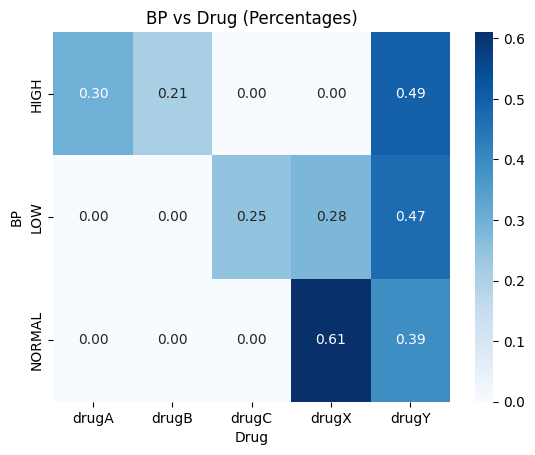

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

ct_pct = pd.crosstab(
    data['BP'],
    data['Drug'],
    normalize='index'
)

sns.heatmap(
    ct_pct,
    annot=True,
    fmt='.2f',
    cmap='Blues'
)

plt.title('BP vs Drug (Percentages)')
plt.xlabel('Drug')
plt.ylabel('BP')
plt.show()


From the heatmap, I can see that drugA and drugB only have high blood pressure, meanwhile only drugs X & Y have normal blood pressure.

So most Normal blood pressures will be predicted to be drugX, while the rest being drugY.

DrugY has all, but it also has by far the most occurences in the dataset.

Above I ran 

```data['Drug'].sort_values().value_counts()```

which showed drugY to have 91/200 occurences in the dataset, which is 45%.

# Training a Random Forest using all Features

In [54]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

preprocess = ColumnTransformer([
    ('Sex', OrdinalEncoder(), ['Sex']),
    ("bp", OrdinalEncoder(categories=[['LOW', 'MEDIUM', 'HIGH']],  handle_unknown='use_encoded_value', unknown_value=-1), ['BP']),
    ("chol", OrdinalEncoder(categories=[['NORMAL', 'HIGH']], handle_unknown='use_encoded_value', unknown_value=-1), ['Cholesterol']),
    ], remainder="passthrough")

X = data.iloc[:,0:5]
y = data.iloc[:, 5]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

pipe1 = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(criterion='entropy'))
])



<h4> Stratified 5 Fold Cross Validation

In [55]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores1 = cross_val_score(
    pipe1,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

print("StratifiedKFoldCV mean accuracy:", cv_scores1.mean())


StratifiedKFoldCV mean accuracy: 0.9928571428571429


<h4> Fit model and get accuracy

In [56]:
pipe1.fit(X_train, y_train)


test_predictions1 = pipe1.predict(X_test)
train_predictions1 = pipe1.predict(X_train)

test_accuracy1 = accuracy_score(y_true=y_test, y_pred=test_predictions1)
train_accuracy1 = accuracy_score(y_true=y_train, y_pred=train_predictions1)
print(f"Training set accuracy: {train_accuracy1}.\tTest set accuracy: {test_accuracy1}")

Training set accuracy: 1.0.	Test set accuracy: 0.9833333333333333


<h4> Look at misclassified records

In [57]:

X_test_with_preds1 = X_test.copy()
X_test_with_preds1["True_Label"] = y_test
X_test_with_preds1["Prediction"] = test_predictions1
X_test_with_preds1.query("True_Label != Prediction")

,Age,Sex,BP,Cholesterol,Na_to_K,True_Label,Prediction
138,51,M,HIGH,NORMAL,11.343,drugB,drugA


# Feature Engineering: Try Binning Age

Maybe binning the Age column might improve the accuracy even more? Worth trying

In [58]:
data.Age.describe()

count    200.000000
mean      44.315000
std       16.544315
min       15.000000
25%       31.000000
50%       45.000000
75%       58.000000
max       74.000000
Name: Age, dtype: float64

In [59]:
from sklearn.preprocessing import KBinsDiscretizer

preprocess = ColumnTransformer([
    ('Sex', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ['Sex']),
    ("bp", OrdinalEncoder(categories=[['LOW', 'MEDIUM', 'HIGH']],
                          handle_unknown='use_encoded_value', unknown_value=-1), ['BP']),
    ("chol", OrdinalEncoder(categories=[['NORMAL', 'HIGH']],
                            handle_unknown='use_encoded_value', unknown_value=-1), ['Cholesterol']),
    ("age", KBinsDiscretizer(
        n_bins=4,
        encode='ordinal',
        strategy='quantile'
    ), ['Age'])
], remainder="passthrough")

pipe2 = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(criterion='entropy'))
])


In [60]:
# cross validate
scores2 = cross_val_score(pipe2, X_train, y_train, cv=cv)
print(scores2.mean())

0.9928571428571429


In [61]:
pipe2.fit(X_train, y_train)
test_predictions2 = pipe2.predict(X_test)
train_predictions2 = pipe2.predict(X_train)

test_accuracy2 = accuracy_score(y_true=y_test, y_pred=test_predictions2)
train_accuracy2 = accuracy_score(y_true=y_train, y_pred=train_predictions2)
print(f"Training set accuracy: {train_accuracy2}.\tTest set accuracy: {test_accuracy2}")

Training set accuracy: 1.0.	Test set accuracy: 0.95


<h4> So binning Age actually decreases accuracy. So the best model for now is the previous one, where Age was numeric

In [62]:
X_test_with_preds2 = X_test.copy()
X_test_with_preds2["True_Label"] = y_test
X_test_with_preds2["Prediction"] = predictions2
X_test_with_preds2.query("True_Label != Prediction")

,Age,Sex,BP,Cholesterol,Na_to_K,True_Label,Prediction
138,51,M,HIGH,NORMAL,11.343,drugB,drugA
110,50,M,HIGH,HIGH,7.490,drugA,drugB
187,47,M,HIGH,HIGH,10.403,drugA,drugB


<h4> With both models, where Age is numeric or binned, they both make the same error of misclassifying datapoint 138 as being drugA while its true label is drugB.

So we can deduce that drugB and drugA are a bit similar, and instance 138 sits well between those two clusters, enough to get misclassified

<h4> Another thing to try: Try dropping Sex column and retraining model, as Sex had very little mutual information with Drug

In [63]:
X_noSex = X.drop("Sex", axis=1)

preprocess = ColumnTransformer([
    ("bp", OrdinalEncoder(categories=[['LOW', 'MEDIUM', 'HIGH']],
                          handle_unknown='use_encoded_value', unknown_value=-1), ['BP']),
    ("chol", OrdinalEncoder(categories=[['NORMAL', 'HIGH']],
                            handle_unknown='use_encoded_value', unknown_value=-1), ['Cholesterol']),
    ("age", KBinsDiscretizer(
        n_bins=4,
        encode='ordinal',
        strategy='quantile'
    ), ['Age'])
], remainder="passthrough")

pipe3 = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(criterion='entropy'))
])

X_train, X_test, y_train, y_test = train_test_split(
    X_noSex, y, test_size=0.3, stratify=y, random_state=42
)


In [64]:
scores3 = cross_val_score(pipe3, X_train, y_train, cv=cv)
print(scores3.mean())

0.9785714285714284


In [65]:
pipe3.fit(X_train, y_train)
test_predictions3 = pipe3.predict(X_test)
train_predictions3 = pipe3.predict(X_train)

test_accuracy3 = accuracy_score(y_true=y_test, y_pred=test_predictions3)
train_accuracy3 = accuracy_score(y_true=y_train, y_pred=train_predictions3)
print(f"Training set accuracy: {train_accuracy3}.\tTest set accuracy: {test_accuracy3}")

Training set accuracy: 1.0.	Test set accuracy: 0.9666666666666667


In [66]:
X_test_with_preds3 = X_test.copy()
X_test_with_preds3["True_Label"] = y_test
X_test_with_preds3["Prediction"] = predictions3

X_test_with_preds3.query("True_Label != Prediction")

,Age,BP,Cholesterol,Na_to_K,True_Label,Prediction
138,51,HIGH,NORMAL,11.343,drugB,drugA
187,47,HIGH,HIGH,10.403,drugA,drugB


In [67]:
print(f"First model accuracy: {test_accuracy1}")
print(f"Second model accuracy: {test_accuracy2}")
print(f"Third model accuracy: {test_accuracy3}")

First model accuracy: 0.9833333333333333
Second model accuracy: 0.95
Third model accuracy: 0.9666666666666667


# Conclusion

<h4> The first model, where we keep Sex and Age column intact, is the best performing model.</h4>



All three models misclassified record 138 as being drugA, while the true label was drugB. 

So record 138 is a unique record as its features resembles drugA features.

Earlier, from the heatmap, I predicted that Normal blood pressures will be mostly drugX, and the rest being drugY. Can confirm below

In [68]:
X_test_with_preds1.query("BP == 'NORMAL'")

,Age,Sex,BP,Cholesterol,Na_to_K,True_Label,Prediction
160,30,F,NORMAL,HIGH,10.443,drugX,drugX
44,50,F,NORMAL,NORMAL,12.295,drugX,drugX
167,57,F,NORMAL,HIGH,14.216,drugX,drugX
6,49,F,NORMAL,HIGH,16.275,drugY,drugY
58,60,M,NORMAL,NORMAL,10.091,drugX,drugX
71,28,F,NORMAL,HIGH,19.675,drugY,drugY
30,18,F,NORMAL,NORMAL,8.750,drugX,drugX
5,22,F,NORMAL,HIGH,8.607,drugX,drugX
152,55,M,NORMAL,NORMAL,7.261,drugX,drugX
34,53,M,NORMAL,HIGH,14.133,drugX,drugX
